# TFM_04_Master_Template: Plantilla de Control Multi-Planta con RL y MLflow

**Objetivo:** Este notebook contiene la estructura base para el entrenamiento de agentes de Reinforcement Learning (RL) en el entorno `ThreePlantEnv`, asegurando el registro sistemático de experimentos y métricas mediante **MLflow**.

## 1) Instalación e Importaciones

In [5]:
# ====================================================================
# I. INSTALACIÓN E IMPORTACIONES
# ====================================================================
# Descomenta la siguiente línea si necesitas instalar las librerías
# %pip install stable-baselines3[extra] gymnasium matplotlib pandas shimmy mlflow

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

# Librerías de RL
from stable_baselines3 import PPO, TD3, SAC
from stable_baselines3.common.monitor import Monitor # CRUCIAL para logs

# MLflow
import mlflow
from mlflow.tracking import MlflowClient

# Configuración de gráficos
plt.style.use('ggplot')
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2) Configuración de MLflow

In [ ]:
# ====================================================================
# II. CONFIGURACIÓN DE MLFLOW
# ====================================================================
EXPERIMENT_NAME = "TFM_Control_MultiPlanta_RL"
TRACKING_URI = "sqlite:///mlflow.db" 

mlflow.set_tracking_uri(TRACKING_URI)

try:
    # Intenta obtener el ID del experimento si ya existe
    experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    if experiment:
        experiment_id = experiment.experiment_id
        print(f"Usando experimento existente: {EXPERIMENT_NAME} (ID: {experiment_id})")
    else:
        experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
        print(f"Creando nuevo experimento: {EXPERIMENT_NAME} (ID: {experiment_id})")
except Exception as e:
    print(f"Nota sobre el experimento: {e}")
    # Fallback seguro
    experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    experiment_id = experiment.experiment_id

# Establece el experimento activo para todas las ejecuciones
mlflow.set_experiment(experiment_id=experiment_id)

# Directorios locales
LOCAL_ARTIFACTS_DIR = "mlflow_local_artifacts"
MONITOR_LOG_DIR = "monitor_logs"
os.makedirs(LOCAL_ARTIFACTS_DIR, exist_ok=True)
os.makedirs(MONITOR_LOG_DIR, exist_ok=True)
print(f"MLflow configurado. Logs en: {MONITOR_LOG_DIR}, Artefactos en: {LOCAL_ARTIFACTS_DIR}")

2025/11/30 21:29:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/11/30 21:29:27 INFO mlflow.store.db.utils: Updating database tables
2025-11-30 21:29:27 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-30 21:29:27 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-11-30 21:29:27 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-30 21:29:27 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


Usando experimento existente: TFM_Control_MultiPlanta_RL (ID: 1)
✅ MLflow configurado. Logs en: monitor_logs, Artefactos en: mlflow_local_artifacts


## 3)Definición del Entorno

In [2]:
# ====================================================================
# III. DEFINICIÓN DEL ENTORNO (DINÁMICO)
# ====================================================================
import numpy as np
import gymnasium as gym
from gymnasium import spaces

# --- FUNCIONES AUXILIARES ---
def generate_complex_profile(length, min_val, max_val, min_step, max_step):
    profile = np.zeros(length)
    current_val = np.random.uniform(min_val, max_val)
    profile[0] = current_val; time = 1
    while time < length:
        step_len = np.random.randint(min_step, max_step)
        next_val = np.random.uniform(min_val, max_val)
        for t in range(time, min(time + step_len, length)):
            profile[t] = current_val + (next_val - current_val) * (t - time) / step_len
        current_val = next_val; time += step_len
    return profile

def generate_square_profile(length, min_val, max_val, min_step, max_step):
    profile = np.zeros(length)
    current_val = np.random.uniform(min_val, max_val); time = 0
    while time < length:
        step = np.random.randint(min_step, max_step)
        profile[time:min(time+step, length)] = current_val
        current_val = np.random.uniform(min_val, max_val); time += step
    return profile

# --- CLASES ---
class FOPDT_Plant:
    def __init__(self, Kp, Tp, Theta):
        self.Kp = Kp; self.Tp = Tp; self.Theta = Theta
        self.y_out = 0.0; self.dead_time_buffer = [0.0] * int(Theta) 
    def step(self, u, dt=1.0):
        self.dead_time_buffer.append(u)
        u_delayed = self.dead_time_buffer.pop(0)
        self.y_out += (dt / self.Tp) * (self.Kp * u_delayed - self.y_out)
        self.y_out += np.random.normal(0, 0.001) 
        self.y_out = max(0.0, self.y_out)
        return self.y_out

class ThreePlantEnv(gym.Env):
    def __init__(self, smoothness_factor=0.1, **kwargs):
        super().__init__()
        self.smoothness_factor = smoothness_factor # Guardamos el factor individual
        
        self.CAPACITIES = np.array([30.0, 80.0, 120.0]) 
        self.MAX_TOTAL_CAPACITY = self.CAPACITIES.sum()
        self.plants = [FOPDT_Plant(1.0, 15, 5), FOPDT_Plant(0.8, 40, 15), FOPDT_Plant(1.1, 25, 8)]
        self.action_space = spaces.Box(low=0.0, high=1.0, shape=(3,), dtype=np.float32)
        self.observation_space = spaces.Box(low=np.array([0,0,0,0,-1,0]), high=np.array([1,1,1,1,1,1]), dtype=np.float32)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.plants = [FOPDT_Plant(1.0, 15, 5), FOPDT_Plant(0.8, 40, 15), FOPDT_Plant(1.1, 25, 8)]
        self.last_action = np.zeros(3); self.t = 0; self.profile_idx = 0
        if options and 'profile' in options: self.episode_profile = options['profile']
        else: self.episode_profile = generate_complex_profile(2000, 0.2, 0.8, 30, 120)
        self.current_setpoint_mw = self.episode_profile[0] * self.MAX_TOTAL_CAPACITY
        return self._get_obs(), {}

    def _get_obs(self):
        outs = np.array([p.y_out for p in self.plants])
        return np.array([
            outs[0]/30.0, outs[1]/80.0, outs[2]/120.0,
            self.current_setpoint_mw/self.MAX_TOTAL_CAPACITY,
            (outs.sum()/self.MAX_TOTAL_CAPACITY) - (self.current_setpoint_mw/self.MAX_TOTAL_CAPACITY),
            self.t/2000.0
        ], dtype=np.float32)

    def step(self, action):
        self.profile_idx += 1; self.t += 1
        terminated = False
        if self.profile_idx < len(self.episode_profile):
            self.current_setpoint_mw = self.episode_profile[self.profile_idx] * self.MAX_TOTAL_CAPACITY
        else: terminated = True; self.current_setpoint_mw = self.episode_profile[-1] * self.MAX_TOTAL_CAPACITY

        for i, p in enumerate(self.plants): p.step(action[i] * self.CAPACITIES[i])
        
        total_out = sum([p.y_out for p in self.plants])
        error = (total_out - self.current_setpoint_mw) / self.MAX_TOTAL_CAPACITY
        
        # --- RECOMPENSA PERSONALIZADA ---
        reward_tracking = -10.0 * (error ** 2)
        
        #USAMOS EL FACTOR INDIVIDUAL
        reward_smoothness = -self.smoothness_factor * np.sum((action - self.last_action)**2)
        
        self.last_action = action
        return self._get_obs(), float(reward_tracking + reward_smoothness), terminated, False, {}

## 4)Funciones Auxiliares

In [4]:
# ====================================================================
# IV. FUNCIONES AUXILIARES (MODIFICADAS PARA ISE Y COSTO CUADRÁTICO)
# ====================================================================
def evaluate_agent_on_profile(model, env, profile):
    """
    Evalúa inyectando un perfil específico.
    Retorna: RMSE (Error Normalizado), Costo Cuadrático Promedio, e ISE Promedio (Error MW).
    """
    obs, info = env.reset(options={'profile': profile})
    
    total_error_sq_norm = 0.0 # Para RMSE
    total_ise_mw = 0.0        # Para ISE (Error NO Normalizado en MW)
    total_actuation_cost_quad = 0.0 # Costo Cuadrático (Consistente con la recompensa)
    total_steps = len(profile)
    # Inicialización de la acción anterior para el cálculo del costo
    prev_action = np.array([0.5] * 3, dtype=np.float32) 
    
    for t in range(total_steps):
        action, _ = model.predict(obs, deterministic=True)
        # El entorno actualiza el setpoint en step()
        obs, _, terminated, _, _ = env.step(action)
        
        total_out = np.array([p.y_out for p in env.plants]).sum()
        
        # 1. Error Normalizado (para RMSE)
        err_norm = (env.current_setpoint_mw - total_out) / env.MAX_TOTAL_CAPACITY
        total_error_sq_norm += err_norm**2
        
        # 2. Error NO Normalizado (para ISE)
        error_mw = env.current_setpoint_mw - total_out
        total_ise_mw += error_mw**2
        
        # 3. Costo Cuadrático (Consistente con la penalización de la recompensa)
        total_actuation_cost_quad += np.sum((action - prev_action)**2)
        prev_action = action
        
    rmse = np.sqrt(total_error_sq_norm / total_steps)
    avg_cost_quad = total_actuation_cost_quad / total_steps
    avg_ise = total_ise_mw / total_steps # ISE promedio
    
    # Devolver las tres métricas
    return rmse, avg_cost_quad, avg_ise

def rollout_and_plot(model, env, profile, title="Resultado"):
    """Genera gráfica inyectando el perfil específico."""
    obs, info = env.reset(options={'profile': profile})
    
    demanda, salida, acciones = [], [], []
    
    # Iteramos len(profile)-1 porque el step avanza al siguiente
    for t in range(len(profile)):
        action, _ = model.predict(obs, deterministic=True)
        
        # Guardar antes del step (estado actual)
        demanda.append(env.current_setpoint_mw)
        
        obs, _, _, _, _ = env.step(action)
        
        salida.append(np.array([p.y_out for p in env.plants]).sum())
        acciones.append(env.last_actions_mw)
    
    df_acc = pd.DataFrame(acciones, columns=['u1', 'u2', 'u3'])
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    ax[0].plot(demanda, 'b--', label='Setpoint')
    ax[0].plot(salida, 'r', label='Salida Total')
    ax[0].set_title(f'Seguimiento - {title}')
    ax[0].set_ylabel('MW'); ax[0].legend(); ax[0].grid(True)
    
    df_acc.plot(ax=ax[1])
    ax[1].set_title('Acciones de Control')
    ax[1].set_ylabel('MW'); ax[1].set_xlabel('Tiempo'); ax[1].grid(True)
    
    plt.tight_layout()
    return fig
print("✅ Funciones auxiliares cargadas.")

✅ Funciones auxiliares cargadas.


## 5) Bucle de Entrenamiento

In [ ]:
# ====================================================================
# V. BUCLE DE ENTRENAMIENTO AUTOMÁTICO (Diseño Factorial)
# ====================================================================
import mlflow
import os
from stable_baselines3 import PPO, TD3, SAC 
from stable_baselines3.common.monitor import Monitor # Importante

TOTAL_TIMESTEPS = 300_000

# Parámetros base
PPO_PARAMS = {
    "learning_rate": 2e-4, "n_steps": 4096, "gamma": 0.99,
    "gae_lambda": 0.98, "n_epochs": 20, "clip_range": 0.1,
    "policy_kwargs": dict(net_arch=[256, 256])
}

TD3_SAC_PARAMS = {
    "learning_rate": 3e-4, "buffer_size": 200000, "gamma": 0.99,
    "policy_kwargs": dict(net_arch=[256, 256])
}

# Estructura de Diseño Factorial
AGENTS_TO_RUN_FACTORIAL = {
    # PPO
    "PPO_Smooth_0_1": (PPO, PPO_PARAMS, 0.1), 
    "PPO_Smooth_0_5": (PPO, PPO_PARAMS, 0.5), 
    "PPO_Smooth_1_5": (PPO, PPO_PARAMS, 1.5), 
    
    # TD3
    "TD3_Smooth_0_1": (TD3, TD3_SAC_PARAMS, 0.1), 
    "TD3_Smooth_0_5": (TD3, TD3_SAC_PARAMS, 0.5), 
    "TD3_Smooth_1_5": (TD3, TD3_SAC_PARAMS, 1.5), 
    
    # SAC
    "SAC_Smooth_0_1": (SAC, TD3_SAC_PARAMS, 0.1), 
    "SAC_Smooth_0_5": (SAC, TD3_SAC_PARAMS, 0.5), 
    "SAC_Smooth_1_5": (SAC, TD3_SAC_PARAMS, 1.5), 
}

# Perfil de evaluación
test_profile_eval = generate_square_profile(2000, 0.1, 0.9, 100, 150) 

print(f"Iniciando Diseño Factorial con {len(AGENTS_TO_RUN_FACTORIAL)} ejecuciones.")

for run_name, (AgentClass, params, smoothness_weight) in AGENTS_TO_RUN_FACTORIAL.items():
    
    with mlflow.start_run(run_name=run_name) as run:
        print(f"\n Ejecutando: {run_name} (Peso: {smoothness_weight})")
        
        # 1. ENTORNO + MONITOR (CRUCIAL PARA GRAFICAS DE APRENDIZAJE)
        env_base = ThreePlantEnv(smoothness_factor=smoothness_weight)
        log_path = os.path.join(MONITOR_LOG_DIR, f"{run_name}.monitor.csv")
        env = Monitor(env_base, filename=log_path) 
        
        # 2. LOGS
        mlflow.log_params(params)
        mlflow.log_param("smoothness_factor", smoothness_weight)
        mlflow.log_param("rl_algorithm", AgentClass.__name__)
        
        # 3. ENTRENAMIENTO
        model = AgentClass("MlpPolicy", env, verbose=0, **params)
        model.learn(total_timesteps=TOTAL_TIMESTEPS)
        
        # 4. GUARDADO DEL MODELO (CRUCIAL PARA CELDA VII)
        save_path = os.path.join(LOCAL_ARTIFACTS_DIR, f"{run_name}_model.zip")
        model.save(save_path)
        print(f" Modelo guardado en: {save_path}")
        
        # 5. EVALUACIÓN FINAL
        env_eval = ThreePlantEnv(smoothness_factor=0.0) 
        rmse, cost_quad, avg_ise = evaluate_agent_on_profile(model, env_eval, test_profile_eval)
        
        mlflow.log_metric("RMSE_Test", rmse)
        mlflow.log_metric("Costo_Actuacion_Cuadratico_Test", cost_quad)
        mlflow.log_metric("ISE_Test", avg_ise)
        
        print(f"FINAL {run_name} -> RMSE: {rmse:.4f} | Costo: {cost_quad:.4f} | ISE: {avg_ise:.4f}")

print("\n🎉 Diseño Factorial completado.")

Iniciando Diseño Factorial con 9 ejecuciones.

🚀 Ejecutando: PPO_Smooth_0_1 (Peso: 0.1)
💾 Modelo guardado en: mlflow_local_artifacts/PPO_Smooth_0_1_model.zip
✅ FINAL PPO_Smooth_0_1 -> RMSE: 0.1252 | Costo: 0.0100 | ISE: 829.2796

🚀 Ejecutando: PPO_Smooth_0_5 (Peso: 0.5)
💾 Modelo guardado en: mlflow_local_artifacts/PPO_Smooth_0_5_model.zip
✅ FINAL PPO_Smooth_0_5 -> RMSE: 0.1244 | Costo: 0.0096 | ISE: 819.0871

🚀 Ejecutando: PPO_Smooth_1_5 (Peso: 1.5)
💾 Modelo guardado en: mlflow_local_artifacts/PPO_Smooth_1_5_model.zip
✅ FINAL PPO_Smooth_1_5 -> RMSE: 0.1523 | Costo: 0.0022 | ISE: 1227.7687

🚀 Ejecutando: TD3_Smooth_0_1 (Peso: 0.1)
💾 Modelo guardado en: mlflow_local_artifacts/TD3_Smooth_0_1_model.zip
✅ FINAL TD3_Smooth_0_1 -> RMSE: 0.1384 | Costo: 0.0135 | ISE: 1013.1181

🚀 Ejecutando: TD3_Smooth_0_5 (Peso: 0.5)
💾 Modelo guardado en: mlflow_local_artifacts/TD3_Smooth_0_5_model.zip
✅ FINAL TD3_Smooth_0_5 -> RMSE: 0.1509 | Costo: 0.0148 | ISE: 1205.0287

🚀 Ejecutando: TD3_Smooth_1_5 (Peso:

## 6)Gráfica de Curva de Aprendizaje

--- Generando Curvas para 9 Agentes ---


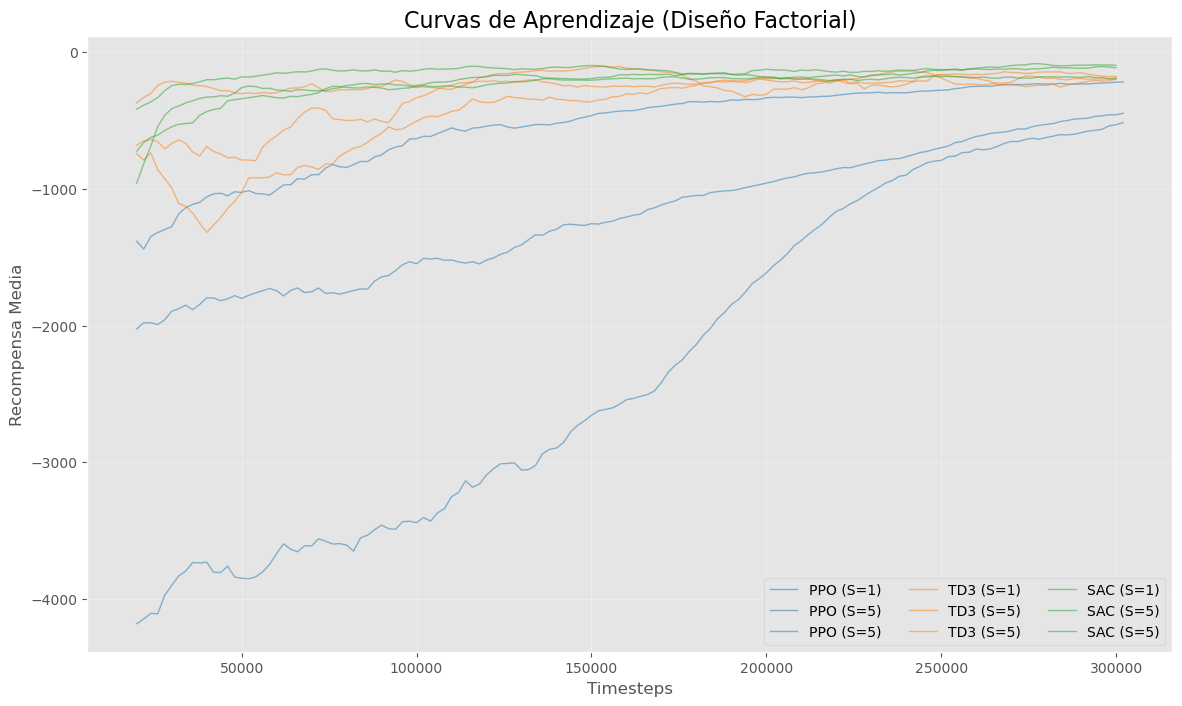

In [6]:
# ====================================================================
# VI. ANÁLISIS: EVOLUCIÓN DE LA RECOMPENSA
# ====================================================================
import pandas as pd
import matplotlib.pyplot as plt

def moving_average(values, window):
    weights = np.repeat(1.0, window) / window
    return np.convolve(values, weights, 'valid')

plt.figure(figsize=(14, 8))

# Colores y Estilos
ALGORITHM_COLORS = {'PPO': 'tab:blue', 'TD3': 'tab:orange', 'SAC': 'tab:green'}
SMOOTHNESS_STYLES = {
    '0.1': {'ls': '-', 'lw': 2.5, 'alpha': 0.9},   # Sólida (Baja penalización)
    '0.5': {'ls': '--', 'lw': 2.0, 'alpha': 0.7},  # Discontinua (Media)
    '1.5': {'ls': ':', 'lw': 1.5, 'alpha': 0.6}    # Punteada (Alta)
}

agents_to_plot = list(AGENTS_TO_RUN_FACTORIAL.keys())
print(f"--- Generando Curvas para {len(agents_to_plot)} Agentes ---")

for agent_name in agents_to_plot:
    parts = agent_name.split('_')
    algo = parts[0]
    # Extraer "0.1" de "Smooth_0_1"
    smooth_val = parts[-1].replace('_', '.') # "0.1"
    
    log_file = os.path.join(MONITOR_LOG_DIR, f"{agent_name}.monitor.csv")
    
    if os.path.exists(log_file):
        try:
            df = pd.read_csv(log_file, skiprows=2, header=None)
            if len(df) > 2:
                df.columns = ['r', 'l', 't']
                x = df['l'].cumsum(); y = df['r']
                
                # Suavizado
                window = max(10, len(y) // 20)
                y_smooth = moving_average(y, window)
                x_smooth = x[len(x) - len(y_smooth):]
                
                style = SMOOTHNESS_STYLES.get(smooth_val, {'ls':'-', 'lw':1, 'alpha':0.5})
                
                plt.plot(x_smooth, y_smooth, 
                         label=f"{algo} (S={smooth_val})", 
                         color=ALGORITHM_COLORS.get(algo, 'gray'),
                         linestyle=style['ls'], linewidth=style['lw'], alpha=style['alpha'])
        except: pass
    else:
        print(f"❌ Falta log: {agent_name}")

plt.title("Curvas de Aprendizaje (Diseño Factorial)", fontsize=16)
plt.ylabel("Recompensa Media"); plt.xlabel("Timesteps")
plt.legend(ncol=3); plt.grid(True, alpha=0.3)
plt.show()

## 7)VISUALIZACIÓN COMPARATIVA FINAL

In [9]:
# Parámetros base
PPO_PARAMS = {
    "learning_rate": 2e-4, "n_steps": 4096, "gamma": 0.99,
    "gae_lambda": 0.98, "n_epochs": 20, "clip_range": 0.1,
    "policy_kwargs": dict(net_arch=[256, 256])
}

TD3_SAC_PARAMS = {
    "learning_rate": 3e-4, "buffer_size": 200000, "gamma": 0.99,
    "policy_kwargs": dict(net_arch=[256, 256])
}

# Estructura de Diseño Factorial
AGENTS_TO_RUN_FACTORIAL = {
    # PPO
    "PPO_Smooth_0_1": (PPO, PPO_PARAMS, 0.1), 
    "PPO_Smooth_0_5": (PPO, PPO_PARAMS, 0.5), 
    "PPO_Smooth_1_5": (PPO, PPO_PARAMS, 1.5), 
    
    # TD3
    "TD3_Smooth_0_1": (TD3, TD3_SAC_PARAMS, 0.1), 
    "TD3_Smooth_0_5": (TD3, TD3_SAC_PARAMS, 0.5), 
    "TD3_Smooth_1_5": (TD3, TD3_SAC_PARAMS, 1.5), 
    
    # SAC
    "SAC_Smooth_0_1": (SAC, TD3_SAC_PARAMS, 0.1), 
    "SAC_Smooth_0_5": (SAC, TD3_SAC_PARAMS, 0.5), 
    "SAC_Smooth_1_5": (SAC, TD3_SAC_PARAMS, 1.5), 
}

# Directorios locales
LOCAL_ARTIFACTS_DIR = "mlflow_local_artifacts"
MONITOR_LOG_DIR = "monitor_logs"

--- Evaluando los 9 agentes del Diseño Factorial ---

🏆 RANKING DE AGENTES (Ordenado por menor Error):


,Agente,Algoritmo,Suavidad (Factor),RMSE (Error),ISE,Costo Actuación (Vibración)
1,PPO_Smooth_0_5,PPO,0.5,17.8695,6.386358e+05,0.0058
0,PPO_Smooth_0_1,PPO,0.1,18.1335,6.576478e+05,0.0081
6,SAC_Smooth_0_1,SAC,0.1,19.6876,7.752002e+05,0.0155
8,SAC_Smooth_1_5,SAC,1.5,19.8333,7.867217e+05,0.0062
7,SAC_Smooth_0_5,SAC,0.5,19.8928,7.914458e+05,0.0157
4,TD3_Smooth_0_5,TD3,0.5,21.3357,9.104239e+05,0.0079
5,TD3_Smooth_1_5,TD3,1.5,21.9819,9.664045e+05,0.0089
3,TD3_Smooth_0_1,TD3,0.1,22.3255,9.968544e+05,0.0107
2,PPO_Smooth_1_5,PPO,1.5,26.9026,1.447504e+06,0.0007


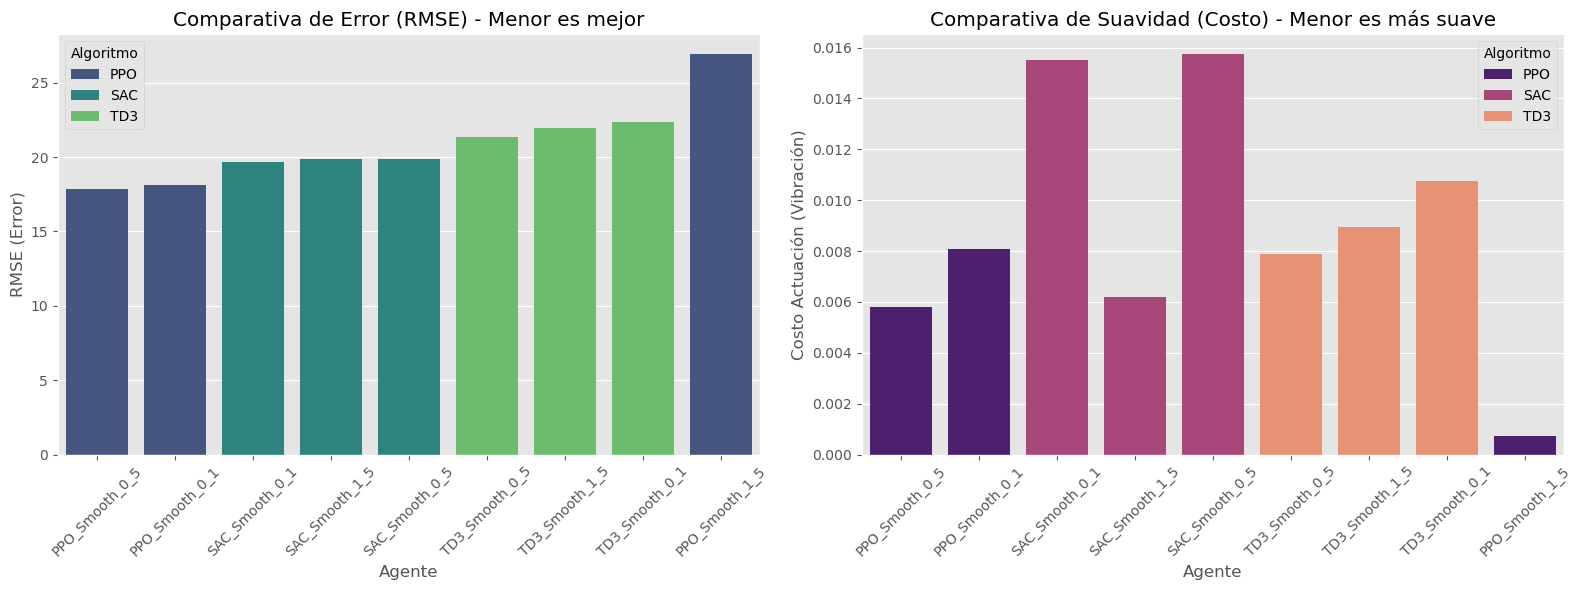


📈 DETALLE VISUAL: RESPUESTA DE CADA AGENTE


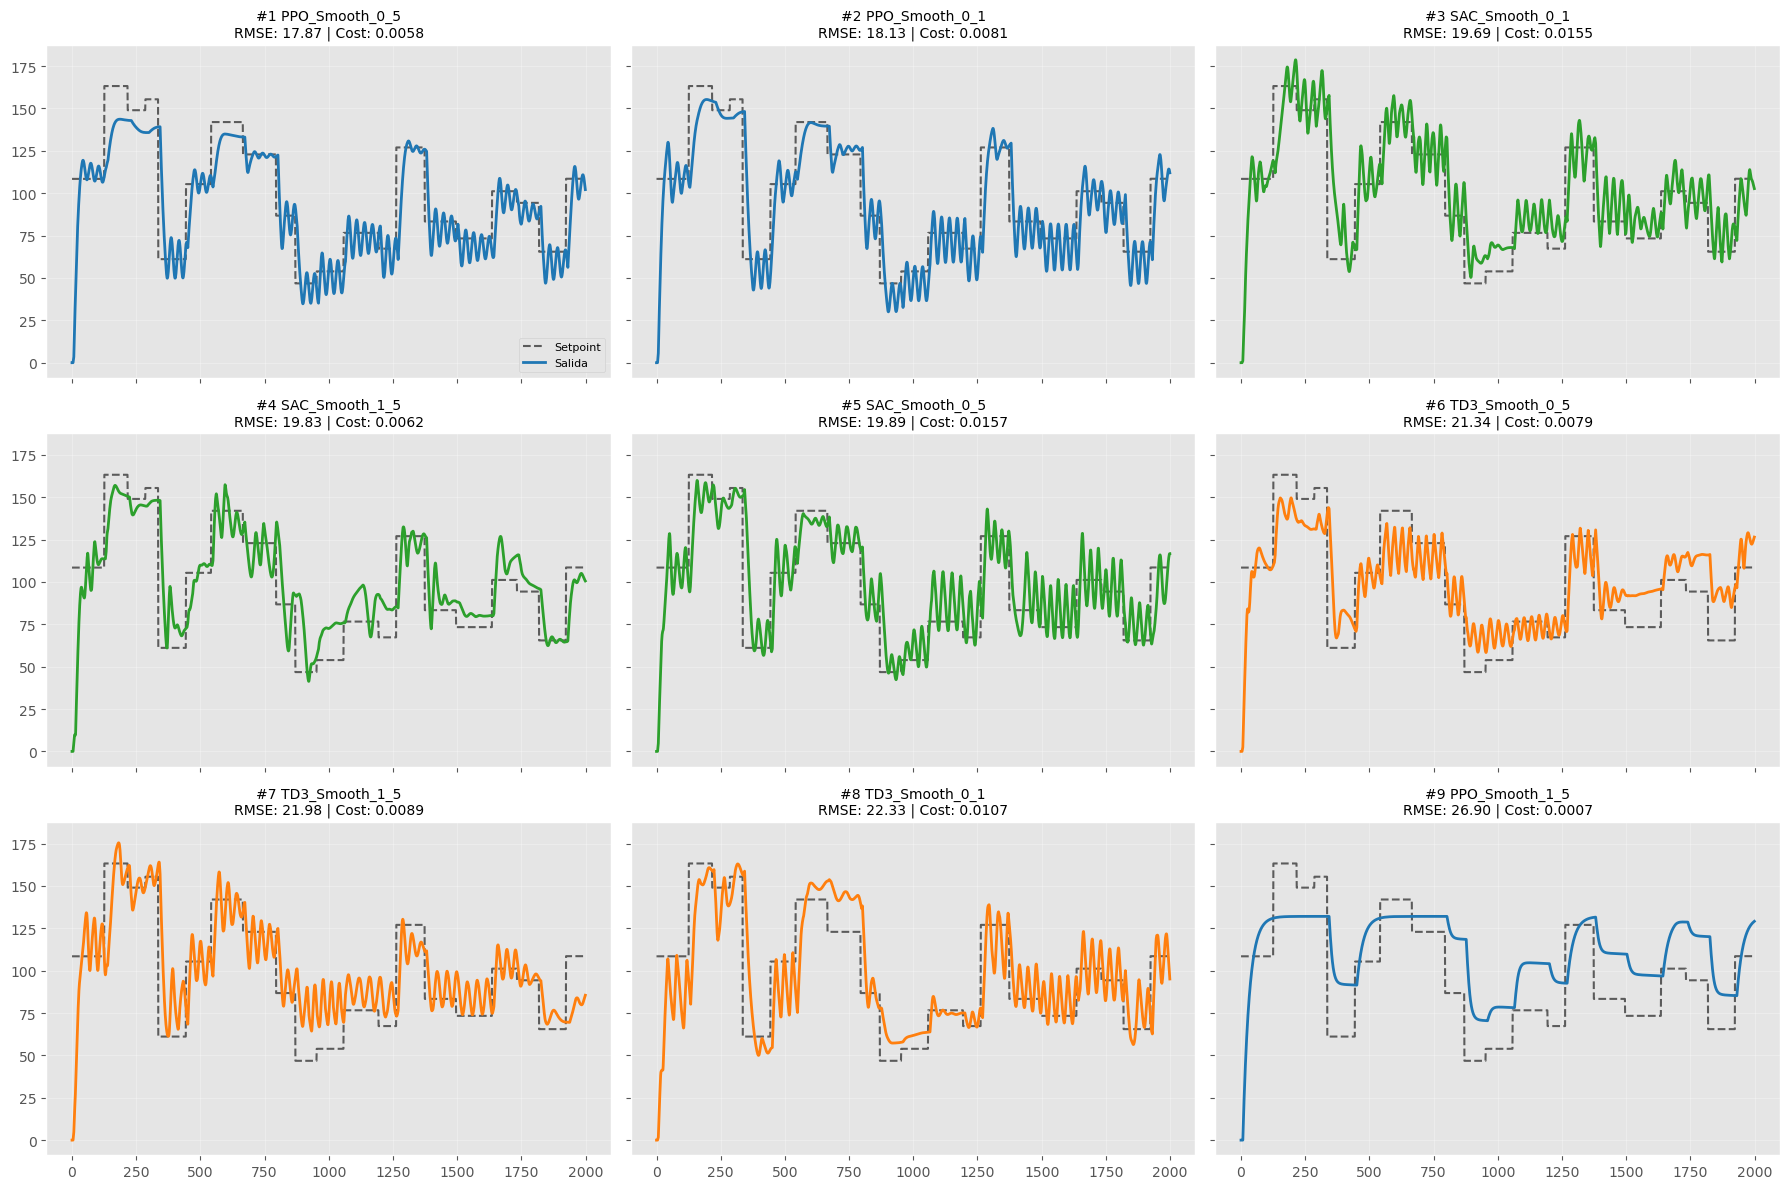

In [10]:
# ====================================================================
# VII. COMPARATIVA TOTAL (RANKING, MÉTRICAS Y GRÁFICAS DE TODOS LOS AGENTES)
# ====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURACIÓN DEL PERFIL DE PRUEBA
# Usamos un perfil unificado para que la comparación sea justa
test_profile = generate_square_profile(2000, 0.2, 0.8, 50, 150)
time_axis = np.arange(2000)

results_data = []
all_time_series = {} # Para guardar las gráficas

print(f"--- Evaluando los {len(AGENTS_TO_RUN_FACTORIAL)} agentes del Diseño Factorial ---")

# 2. EVALUACIÓN MASIVA
for name, (AgentClass, params, smooth_weight) in AGENTS_TO_RUN_FACTORIAL.items():
    model_path = os.path.join(LOCAL_ARTIFACTS_DIR, f"{name}_model.zip")
    
    if not os.path.exists(model_path):
        print(f"⚠️ Modelo no encontrado: {name} (Saltando...)")
        continue

    # Cargar modelo en entorno limpio (sin penalización en recompensa para evaluación justa)
    env_eval = ThreePlantEnv(smoothness_factor=0.0)
    try:
        model = AgentClass.load(model_path, env=env_eval)
        obs, _ = env_eval.reset(options={'profile': test_profile})
        
        # Arrays para guardar la respuesta de este agente
        y_real = []
        u_actions = []
        
        # Ejecutar episodio
        for _ in range(len(test_profile)):
            action, _ = model.predict(obs, deterministic=True)
            obs, _, _, _, _ = env_eval.step(action)
            
            # Guardar datos
            total_out = sum(p.y_out for p in env_eval.plants)
            y_real.append(total_out)
            
            # Calcular cambio de acción (coste de suavidad real)
            # Asumimos que la acción anterior está en env_eval.last_action (o lo aproximamos)
            if len(u_actions) > 0:
                delta = np.sum((action - u_actions[-1])**2)
            else:
                delta = 0.0
            u_actions.append(action)
            
        # Calcular Métricas Globales
        y_real = np.array(y_real)
        setpoint = np.array([env_eval.episode_profile[t] * env_eval.MAX_TOTAL_CAPACITY for t in range(len(test_profile))])
        
        rmse = np.sqrt(np.mean((setpoint - y_real)**2))
        ise = np.sum((setpoint - y_real)**2)
        # Costo de actuación promedio (suma de diferencias al cuadrado)
        u_actions = np.array(u_actions)
        actuation_cost = np.mean(np.sum(np.diff(u_actions, axis=0)**2, axis=1))
        
        # Guardar resultados
        results_data.append({
            "Agente": name,
            "Algoritmo": name.split('_')[0],
            "Suavidad (Factor)": smooth_weight,
            "RMSE (Error)": rmse,
            "ISE": ise,
            "Costo Actuación (Vibración)": actuation_cost
        })
        
        # Guardar serie temporal para plotear luego
        all_time_series[name] = {
            "y_real": y_real,
            "setpoint": setpoint
        }
        
    except Exception as e:
        print(f"❌ Error evaluando {name}: {e}")

# 3. CREAR DATAFRAME Y MOSTRAR TABLA
if results_data:
    df_results = pd.DataFrame(results_data)
    # Ordenar por RMSE (el mejor tracking primero)
    df_results = df_results.sort_values(by="RMSE (Error)", ascending=True)
    
    print("\n🏆 RANKING DE AGENTES (Ordenado por menor Error):")
    display(df_results.round(4))
    
    # 4. VISUALIZACIÓN DE MÉTRICAS (BARRAS)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfica 1: RMSE (Error)
    sns.barplot(data=df_results, x="Agente", y="RMSE (Error)", hue="Algoritmo", ax=axes[0], palette="viridis")
    axes[0].set_title("Comparativa de Error (RMSE) - Menor es mejor")
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfica 2: Costo de Actuación (Suavidad)
    sns.barplot(data=df_results, x="Agente", y="Costo Actuación (Vibración)", hue="Algoritmo", ax=axes[1], palette="magma")
    axes[1].set_title("Comparativa de Suavidad (Costo) - Menor es más suave")
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # 5. GRÁFICA DE RESPUESTA TEMPORAL (GRILLA 3x3)
    # Organizamos los plots en una cuadrícula para verlos todos
    print("\n📈 DETALLE VISUAL: RESPUESTA DE CADA AGENTE")
    num_agents = len(results_data)
    cols = 3
    rows = (num_agents // cols) + (1 if num_agents % cols > 0 else 0)
    
    fig2, axes2 = plt.subplots(rows, cols, figsize=(18, 4 * rows), sharex=True, sharey=True)
    axes2 = axes2.flatten()
    
    # Reordenamos para plotear en el mismo orden del ranking (mejores primero)
    for i, row in enumerate(df_results.itertuples()):
        name = row.Agente
        ax = axes2[i]
        
        data = all_time_series[name]
        ax.plot(time_axis, data["setpoint"], 'k--', alpha=0.6, label="Setpoint")
        
        # Color según algoritmo
        color = 'tab:blue' if 'PPO' in name else ('tab:orange' if 'TD3' in name else 'tab:green')
        
        ax.plot(time_axis, data["y_real"], color=color, linewidth=2, label="Salida")
        
        ax.set_title(f"#{i+1} {name}\nRMSE: {row._4:.2f} | Cost: {row._6:.4f}", fontsize=10)
        ax.grid(True, alpha=0.3)
        if i == 0: ax.legend(loc="lower right", fontsize=8)
    
    # Ocultar ejes vacíos si hay menos de 9
    for j in range(i+1, len(axes2)):
        axes2[j].axis('off')
        
    plt.tight_layout()
    plt.show()

else:
    print("❌ No se obtuvieron resultados. Verifica que la Celda V haya terminado y guardado los modelos.")